## Setup

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import time
import os
import re
from datetime import datetime
import matplotlib.pyplot as plt

# User Configuration
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

def scrape_weather_data(city):
    """Scrapes current weather data from timeanddate.com"""
    url = f"https://www.timeanddate.com/weather/philippines/{city.lower().replace(' ', '-')}"
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'lxml')
        
        # Extract main attributes [cite: 683, 685, 688, 689]
        temp_raw = soup.find('div', class_='h2').text.strip()
        # Clean non-breaking spaces and '°C' [cite: 697, 721]
        temp = re.sub(r'[^\d]', '', temp_raw) 
        condition = soup.find('div', id='qlook').find('p').text.strip()
        
        # Extract table details [cite: 688, 689, 690]
        details = soup.find('table', id='qfacts').find_all('td')
        humidity = re.sub(r'[^\d]', '', details[5].text)
        pressure = re.sub(r'[^\d]', '', details[6].text)
        
        return {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "city": city.title(),
            "temperature": int(temp),
            "condition": condition,
            "humidity": int(humidity),
            "pressure": int(pressure)
        }
    except Exception as e:
        print(f"Error scraping {city}: {e}")
        return None

## 1. Daily Weather Logger (CSV Output)

In [15]:
import requests, pandas as pd, os, time
from datetime import datetime

def scrape_weather_data(city):
    try:
        url = f"https://wttr.in/{city}?format=j1"
        response = requests.get(url, timeout=10)
        data = response.json()
        current = data['current_condition'][0]
        return {
            'timestamp': datetime.now().isoformat(),
            'city': city,
            'temperature': current['temp_C'],
            'feels_like': current['FeelsLikeC'],
            'humidity': current['humidity'],
            'condition': current['weatherDesc'][0]['value'],
            'wind': current['windspeedKmph']
        }
    except Exception as e:
        print(f"Error scraping {city}: {e}")
        return None

target_city = input("Enter Philippine City: ")
sim_days = int(input("Enter number of simulated days (default 3): ") or 3)
csv_filename = 'weather_data.csv'

print(f"--- Starting Weather Logger for {target_city} ---")
for i in range(sim_days):
    weather_entry = scrape_weather_data(target_city)
    if weather_entry:
        df = pd.DataFrame([weather_entry])
        df.to_csv(csv_filename, mode='a', index=False, header=not os.path.exists(csv_filename))
        print(f"Day {i+1} Logged: {weather_entry['temperature']}°C - {weather_entry['condition']}")
    if i < sim_days - 1:
        print("Waiting 10 seconds...")
        time.sleep(10)

--- Starting Weather Logger for Manila ---
Day 1 Logged: 34°C - Sunny
Waiting 10 seconds...
Day 2 Logged: 34°C - Sunny
Waiting 10 seconds...
Day 3 Logged: 34°C - Sunny


## 2. JSON Weather Exporter

In [10]:
import requests, json, os
from datetime import datetime

city = input("Enter city name: ") or "Manila"
url = f"https://wttr.in/{city}?format=j1"

response = requests.get(url)
data = response.json()

current = data['current_condition'][0]
record = {
    'timestamp': datetime.now().isoformat(),
    'city': city,
    'temperature': current['temp_C'],
    'feels_like': current['FeelsLikeC'],
    'humidity': current['humidity'],
    'condition': current['weatherDesc'][0]['value'],
    'wind': current['windspeedKmph']
}

json_filename = 'weather_data.json'
all_data = json.load(open(json_filename)) if os.path.exists(json_filename) else []
all_data.append(record)
with open(json_filename, 'w') as f:
    json.dump(all_data, f, indent=4)

print(f"Record saved: {record}")

Record saved: {'timestamp': '2026-04-25T18:49:55.733235', 'city': 'Manila', 'temperature': '34', 'feels_like': '38', 'humidity': '50', 'condition': 'Sunny', 'wind': '23'}


## 3. Forecast Data Visualizer

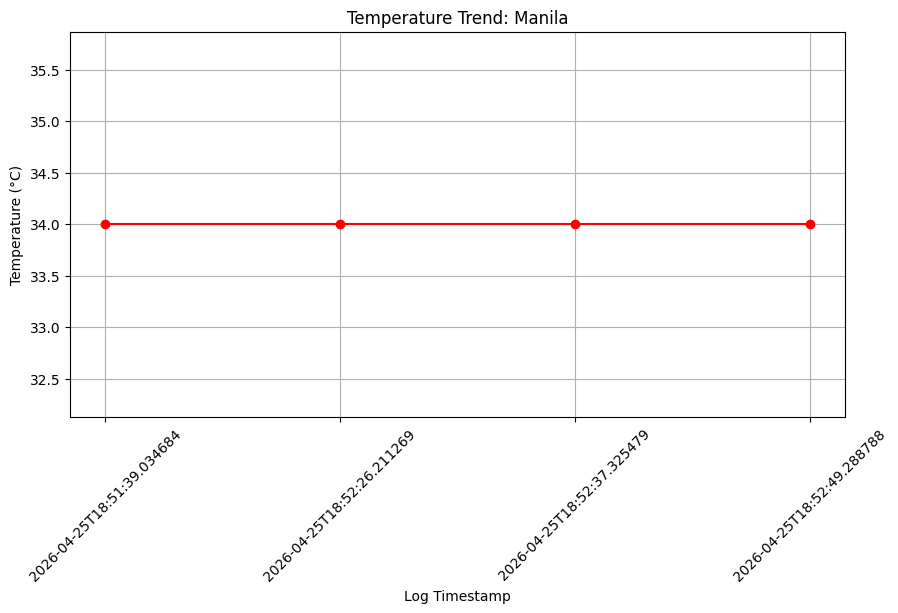

In [16]:
# Read from the CSV generated in Exercise 1 [cite: 737]
if os.path.exists(csv_filename):
    df_plot = pd.read_csv(csv_filename)
    # Filter for selected city [cite: 737]
    city_df = df_plot[df_plot['city'] == target_city.title()]

    if not city_df.empty:
        plt.figure(figsize=(10, 5))
        plt.plot(city_df['timestamp'], city_df['temperature'], marker='o', linestyle='-', color='red')
        
        # Label axes and title [cite: 741]
        plt.title(f"Temperature Trend: {target_city.title()}")
        plt.xlabel("Log Timestamp")
        plt.ylabel("Temperature (°C)")
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("No data available for the selected city.")
else:
    print("CSV file not found. Run Exercise 1 first.")